#Instrucciones para examen

Objetivo: Este examen tiene como objetivo evaluar la capacidad del estudiante para limpiar, explorar, implementar y evaluar modelos de regresión en un dataset de ventas de retail. Utilizaremos el «Retail Sales Dataset» disponible en Kaggle. Los estudiantes deben demostrar habilidades prácticas en la manipulación de datos, creación de visualizaciones y modelado predictivo.



##Contexto y Descripción del Dataset

El «Retail Sales Dataset» contiene datos históricos de ventas de retail, incluidos detalles sobre las ventas diarias de diversas categorías de productos. La tarea es predecir las ventas futuras basándose en varias características que describen productos, categorías y fechas de venta.



##Diccionario de Datos

* Transaction ID: Un identificador único para cada transacción, que permite el seguimiento y la referencia.
* Date: La fecha en que ocurrió la transacción, proporcionando información sobre las tendencias de ventas a lo largo del tiempo.
* Customer ID: Un identificador único para cada cliente, que permite un análisis centrado en el cliente.
* Gender: El género del cliente (Masculino/Femenino), ofreciendo información sobre patrones de compra basados en el género.
* Age: La edad del cliente, facilitando la segmentación y exploración de influencias relacionadas con la edad.
* Product Category: La categoría del producto comprado (por ejemplo, Electrónica, Ropa, Belleza), ayudando a entender las preferencias de productos.
* Quantity: El número de unidades del producto comprado, contribuyendo a información sobre volúmenes de compra.


Requisitos

1.  Limpieza de Datos:
* Identificación y eliminación de valores duplicados: Asegúrate de que no haya registros duplicados que puedan sesgar los resultados del análisis.
* Verificación y ajuste de tipos de datos: Verifica que cada columna tenga el tipo de dato correcto (numérico o categórico) y ajusta si es necesario.
* Corrección de inconsistencias en valores categóricos: Revisa las categorías de las variables y unifica aquellos valores que puedan estar escritos de diferentes maneras pero que representen lo mismo.
* Manejo de valores faltantes adecuadamente: Identifica y maneja los valores faltantes utilizando técnicas apropiadas como la imputación de la mediana, media o moda, según corresponda.
2.  Exploración de Datos:
* Visualizaciones univariadas y multivariadas: Crea histogramas, gráficos de barras, diagramas de dispersión y mapas de calor para entender la distribución y las relaciones entre las variables.
* Estadísticas descriptivas: Calcula medidas de tendencia central (media, mediana, moda) y de dispersión (rango, desviación estándar) para cada característica del dataset.
3.  Implementación de Modelos:
* Modelos de Regresión: Implementa modelos de Decision Tree Regressor y Random Forest Regressor.
* Optimización de Modelos: Utiliza GridSearchCV para optimizar los hiperparámetros de los modelos.
* Evaluación de Modelos: Evalúa los modelos utilizando métricas como MSE, RMSE, y R^2.
* Comparación de Rendimiento: Compara los resultados de ambos modelos y discute cuál es el más adecuado para este dataset.


##Entrega

Los estudiantes deben entregar un archivo .ipynb comentado que incluya:

* Proceso completo de limpieza y preprocesamiento de datos.
* Visualizaciones y estadísticas descriptivas.
* Implementación y evaluación de los modelos de regresión.
* Análisis comparativo del rendimiento de los modelos.
Además, el archivo debe subirse a GitHub con un tag de liberación (release tag) que permita identificar la entrega final.



##Consideraciones Éticas y Tecnológicas

###Consideraciones Éticas:

* Transparencia y Reproducibilidad: Asegúrate de que todos los pasos del análisis sean claros y reproducibles. Otros investigadores deben poder seguir tus pasos y llegar a los mismos resultados.
* Imparcialidad y Sesgo: Revisa si existen sesgos en los datos que puedan afectar la imparcialidad del modelo. Es importante que los modelos no discriminen injustamente entre diferentes grupos de datos.

###Consideraciones Tecnológicas:

* Herramientas Utilizadas: Utiliza herramientas estándar como Python, Jupyter Notebook, Pandas, Scikit-learn, Matplotlib y Seaborn.
* Escalabilidad: Considera cómo las técnicas aplicadas podrían escalarse para manejar conjuntos de datos más grandes y complejos.
* Optimización de Modelos: Utiliza técnicas como GridSearchCV para optimizar los hiperparámetros y mejorar el rendimiento de los modelos.


Link del Dataset
[Aqui](https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset)

#Desarrollo

###Instalacion LazyPredict

In [1]:
!pip install lazypredict --quiet

###Importacion de Liberias.

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

###Carga de DataSet

In [3]:
df = pd.read_csv('retail_sales_dataset.csv')

Carga el archivo retail_sales.csv en un DataFrame de Pandas.


###Dimensiones del DataSet

In [4]:
df.shape

(1000, 9)

Se verifican la dimensiones en donde tenemos  1000 registros o filas y 9 atributos o columnas.

In [5]:
df.head(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Se realiza un despligue visual de los primeros 5 registros del DataFrame

In [6]:
df.tail(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


Se realiza un despligue visual de los ultimos 5 registros del DataFrame

###Informacion del DataFrame

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


se realiza un reporte conciso del DataFrame, del cual se determina los siguientes puntos.

* en primera vista el DataFrame no Posee Datos Nulos en su totalidad.
* 'Transaction ID', 'Age', 'Quantity', 'Price per Unit' y 'TotalAmount' son Calumnas con datos numericos
* 'Date', 'Customer ID', 'Gender' y 'Product Category" de tipo String, no se declaran como Categoricos aun ya que estos pueden sufrir cambios a futuro.


In [8]:
# Duplicados
n_duplicados = df.duplicated(['Transaction ID']).sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


###Reporte Tipos de Datos




In [9]:
print(df.dtypes)

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


###Reporte Valores Únicos

In [10]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [11]:
print("Distribución por Categoria de producto:")
print(df['Product Category'].value_counts())

Distribución por Categoria de producto:
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


* El dataset no contiene la columna productos, para el caso se utiliza la columna Product Category, ya que esta nos puede mostar cual es la linea de productos que genera mayores ventas.
* El dataset no contiene la columna "Tienda", para este caso se utiliza la columna Age, ya que esta con el metodo unique puede mostrar el segmento etario que compra.

In [12]:
for column in df.columns:
    print(f"Valores únicos en la columna '{column}':")
    print(df[column].unique())
    print("\n" + "-" * 30 + "\n")

Valores únicos en la columna 'Transaction ID':
[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188

###Reporte de Valores Nulos

In [13]:
null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('Columnas con valores nulos ')
display(null_report)

Columnas con valores nulos 


,Nulos,Porcentaje,Umbral


el reporte arroja que el DataFrame se encuentra 100% limpia

###Corrección de Inconsistencias

In [14]:
mapping_doors = {
    'Male': 1,
    'Female': 0
}
# Aplicamos los cambios al DataFrame
df['Gender'] = df['Gender'].map(mapping_doors)

 Los algoritmos de machine learning como Scikit-Learn solo procesan números. No entienden palabras como "Male" o "Female". La cual es la razon de generar este cambio sobre los datos de la columna 'Gender'

In [15]:
df.head(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,1,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,0,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,1,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,1,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,1,30,Beauty,2,50,100


###Conversión de Tipos De Datos

In [16]:
df['Date'] = pd.to_datetime(df['Date'])
df['Transaction ID'] = df['Transaction ID'].astype(str)
df['Customer ID'] = df['Customer ID'].astype(str)
df['Gender'] = df['Gender'].astype(bool)

Algunas columnas se convertiran el tipo de dato con el fin de que los datos almacenados sean considerado  por los  modelos de regresion.


In [17]:
print(df.dtypes)

Transaction ID              object
Date                datetime64[ns]
Customer ID                 object
Gender                        bool
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


In [18]:
df.head(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,True,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,False,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,True,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,True,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,True,30,Beauty,2,50,100


###Feature Engineering

In [19]:
df['Month'] = df['Date'].dt.month_name()
df.head(2)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
0,1,2023-11-24,CUST001,True,34,Beauty,3,50,150,November
1,2,2023-02-27,CUST002,False,26,Clothing,2,500,1000,February


In [20]:
# Extraer el trimestre (devuelve 1, 2, 3 o 4)
df['Quarter'] = df['Date'].dt.quarter
df.head(2)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-11-24,CUST001,True,34,Beauty,3,50,150,November,4
1,2,2023-02-27,CUST002,False,26,Clothing,2,500,1000,February,1


El DataFrame puede pasar por un procesoa de ingenieria de caracteristicas, esto con el fin de crear Features que aporten a los modelos en la toma de desiciones.

*  El Primer Bloque de codigo de la seccion extrae el mes de la fecha de Compra y genera una columna 'Month' con este dato.
*  El segundo Bloque de codigo de la seccion calcula el trimestre al que pertenece la fecha de compra y genera una columna 'Quarter' con este dato.

In [21]:
df['Week'] = df['Date'].dt.isocalendar().week
df.head(15)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Week
0,1,2023-11-24,CUST001,True,34,Beauty,3,50,150,November,4,47
1,2,2023-02-27,CUST002,False,26,Clothing,2,500,1000,February,1,9
2,3,2023-01-13,CUST003,True,50,Electronics,1,30,30,January,1,2
3,4,2023-05-21,CUST004,True,37,Clothing,1,500,500,May,2,20
4,5,2023-05-06,CUST005,True,30,Beauty,2,50,100,May,2,18
5,6,2023-04-25,CUST006,False,45,Beauty,1,30,30,April,2,17
6,7,2023-03-13,CUST007,True,46,Clothing,2,25,50,March,1,11
7,8,2023-02-22,CUST008,True,30,Electronics,4,25,100,February,1,8
8,9,2023-12-13,CUST009,True,63,Electronics,2,300,600,December,4,50
9,10,2023-10-07,CUST010,False,52,Clothing,4,50,200,October,4,40


In [22]:
# Asegurar que la columna 'Date' sea interpretada como fecha
df['Date'] = pd.to_datetime(df['Date'])

# Crear una columna con el formato 'Año-Mes' para poder agrupar fácilmente
df['Year_Month'] = df['Date'].dt.to_period('M')

# Agrupar por mes y sumar el total de ventas
ventas_mensuales = df.groupby('Year_Month')['Total Amount'].sum().reset_index()

# Convertir de nuevo a timestamp para que Matplotlib maneje el eje X de forma correcta
ventas_mensuales['Year_Month'] = ventas_mensuales['Year_Month'].dt.to_timestamp()

# Filtrar el rango solicitado: desde Febrero 2023 hasta Febrero 2024
inicio_periodo = '2023-02-01'
fin_periodo = '2024-02-29'
ventas_filtradas = ventas_mensuales[
    (ventas_mensuales['Year_Month'] >= inicio_periodo) &
    (ventas_mensuales['Year_Month'] <= fin_periodo)
].sort_values('Year_Month')

In [23]:
df['purchase_level'] = df['Total Amount'].apply(lambda x: 'Low' if x <= 258 else ('Medium' if x <= 1317 else 'High'))
df.head(2)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Week,Year_Month,purchase_level
0,1,2023-11-24,CUST001,True,34,Beauty,3,50,150,November,4,47,2023-11,Low
1,2,2023-02-27,CUST002,False,26,Clothing,2,500,1000,February,1,9,2023-02,Medium


Se crea la columna "purchase_level" para categorizar el nivel de las ventas, las categorias son:

*   total de la venta menor o igual 258, su nivel es Low "bajo"
*   total de la venta menor o igual 1317, su nivel es Medium "medio"
*   total de la venta mayor 1317, su nivel es High "alto"



In [24]:
print(df.dtypes)

Transaction ID              object
Date                datetime64[ns]
Customer ID                 object
Gender                        bool
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
Month                       object
Quarter                      int32
Week                        UInt32
Year_Month               period[M]
purchase_level              object
dtype: object


In [25]:
df['Quarter'] = df['Quarter'].astype('int64')
df['Week'] = df['Week'].astype('int64')

In [26]:
print(df.dtypes)

Transaction ID              object
Date                datetime64[ns]
Customer ID                 object
Gender                        bool
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
Month                       object
Quarter                      int64
Week                         int64
Year_Month               period[M]
purchase_level              object
dtype: object


##Estadísticas Descriptivas

In [27]:
# Columnas numéricas de interés
num_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

for col in num_cols:
    if col in df.columns:
        print(f"\n--- Variable: {col} ---")
        print(f"Media:              {df[col].mean():.2f}")
        print(f"Mediana:            {df[col].median():.2f}")
        print(f"Moda:               {df[col].mode()[0]:.2f}")
        print(f"Desviación Estándar:{df[col].std():.2f}")
        print(f"Rango:              {df[col].max() - df[col].min():.2f}")


--- Variable: Age ---
Media:              41.39
Mediana:            42.00
Moda:               43.00
Desviación Estándar:13.68
Rango:              46.00

--- Variable: Quantity ---
Media:              2.51
Mediana:            3.00
Moda:               4.00
Desviación Estándar:1.13
Rango:              3.00

--- Variable: Price per Unit ---
Media:              179.89
Mediana:            50.00
Moda:               50.00
Desviación Estándar:189.68
Rango:              475.00

--- Variable: Total Amount ---
Media:              456.00
Mediana:            135.00
Moda:               50.00
Desviación Estándar:560.00
Rango:              1975.00


##Visualizaciones

###Distribución de la Edad - Ventas por Categoría de Producto - Distribución del Nivel de Compra

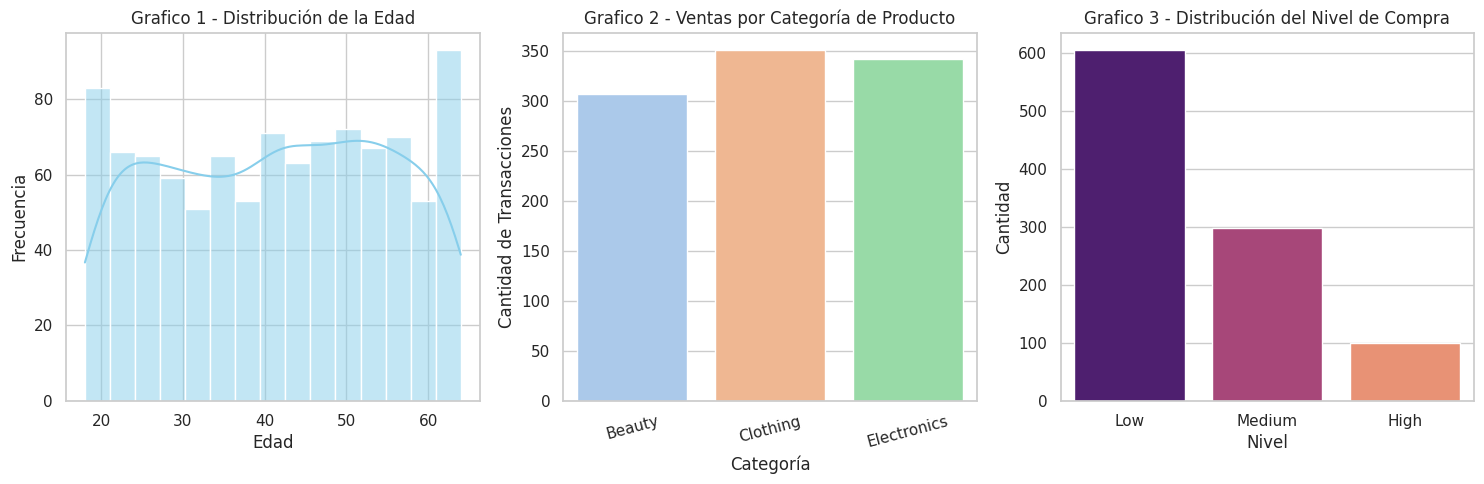

In [28]:
sns.set_theme(style="whitegrid")

fig1, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histograma: Distribución de la Edad
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Grafico 1 - Distribución de la Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Gráfico de Barras: Categorías de Productos
sns.countplot(data=df, x='Product Category', palette='pastel', hue='Product Category', legend=False, ax=axes[1])
axes[1].set_title('Grafico 2 - Ventas por Categoría de Producto')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Cantidad de Transacciones')
axes[1].tick_params(axis='x', rotation=15)

# Gráfico de Barras: Nivel de Compra (purchase_level)
if 'purchase_level' in df.columns:
    sns.countplot(data=df, x='purchase_level', palette='magma', order=['Low', 'Medium', 'High'], hue='purchase_level', legend=False, ax=axes[2])
    axes[2].set_title('Grafico 3 - Distribución del Nivel de Compra')
    axes[2].set_xlabel('Nivel')
    axes[2].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

fig1.savefig('grafico1.png', dpi=300, bbox_inches='tight')
plt.close(fig1)

Grafico #1 Histograma grupos etarios. el grafico muestra  una distribucion multimodal o aproximadamente uniforme,este grafico muestra una distribucion relativamente llama con fluctuaciones, lo que significa que la distribucion entre los 20 a los 60 es bantante equitativa. Teniendo  pico en el extremo derecho indicando que el grupo etario preferente del retail son los adultos mayores de 63 años, bien el pico de la izquierda muestra que el segundo grupo etario del retail don los jovenes de 18 - 19 años.

Grafico #2, el grafico muestra  que las 3 categorias de productos del retail generan ventas de forma casi equitativa de la cual sobre sale el vesturios, bien esta genera la mayor cantidad de ventas las  otras categorias no se quedan atras. por lo cual podemos decir que el retail no depende de una unica categoria de productos para sus ingresos.

Grafico #3. El grafico muestra la cantidad de compras categorizadas por el nivel (low, medium y high), bien aprox. el 60% de las transacciones son de bajo nivel quiere de decir no son por montos muy altos y son las transacciones que soportan la caja operativa del retail, quedan el otro 40 % aprox distribuida en mediun y high  que son compar mas esporadicas. Este tipo de escenario son propicio par que las areas comerciales apliquen tecnicas que muevan parte de las transacciones de bajo nivel a medium a travez de tecnicas como combos en productos, fortalecion los ingresos y el nivel de compra.

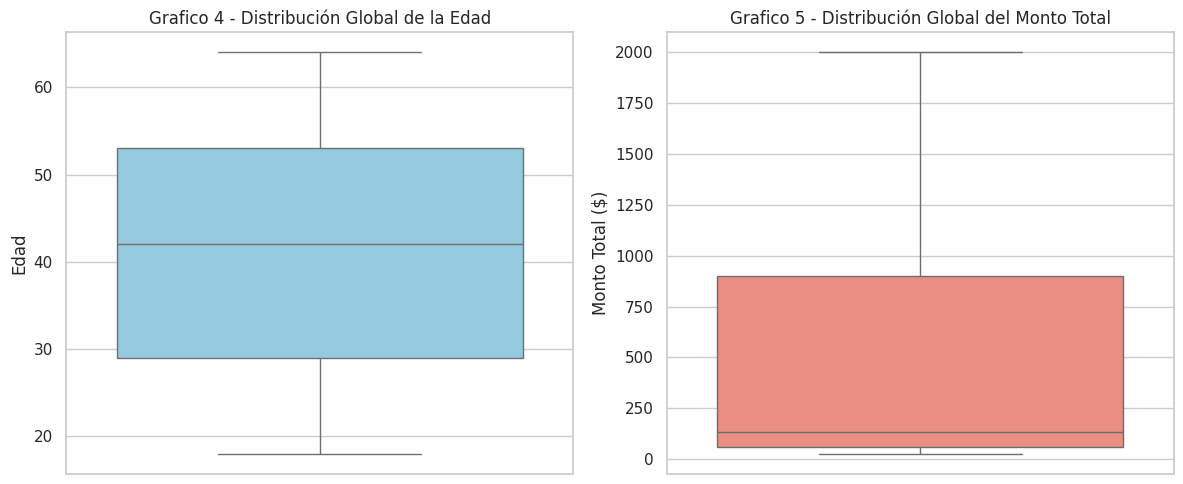

In [29]:
# Configuración de estilo
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot de Edad
sns.boxplot(data=df, y='Age', color='skyblue', ax=axes[0])
axes[0].set_title('Grafico 4 - Distribución Global de la Edad')
axes[0].set_ylabel('Edad')

# Boxplot de Total Amount
sns.boxplot(data=df, y='Total Amount', color='salmon', ax=axes[1])
axes[1].set_title('Grafico 5 - Distribución Global del Monto Total')
axes[1].set_ylabel('Monto Total ($)')

plt.tight_layout()
plt.show()
fig.savefig('grafico2.png', dpi=300, bbox_inches='tight')
plt.close(fig)


Grafico #5. Este grafico confirma que el negocio tiene un atractivo trasnversal que se correlaciona y confirma con el grafico #1, al no estar concentrado en un nicho especifico toda accion comercial debe ser analizada con cuidado. Asi tambien le gra visualizar que no existen datos outliers en la edades.

Grafico #6. Este grafico es una radiografia financiera que confirma que el nogicio funciona bajo un modelo de volumen sostiene los ingresos. la mayor parte de la transacciones son ventas categorizadas de bajo nivel y que las ventas de alto nivel son ventas espeficicas y esporadicas con las cuales no puedo sostener la caja operativa.

###Tendencia Mensual de Ventas Totales (Feb 2023 - Feb 2024)

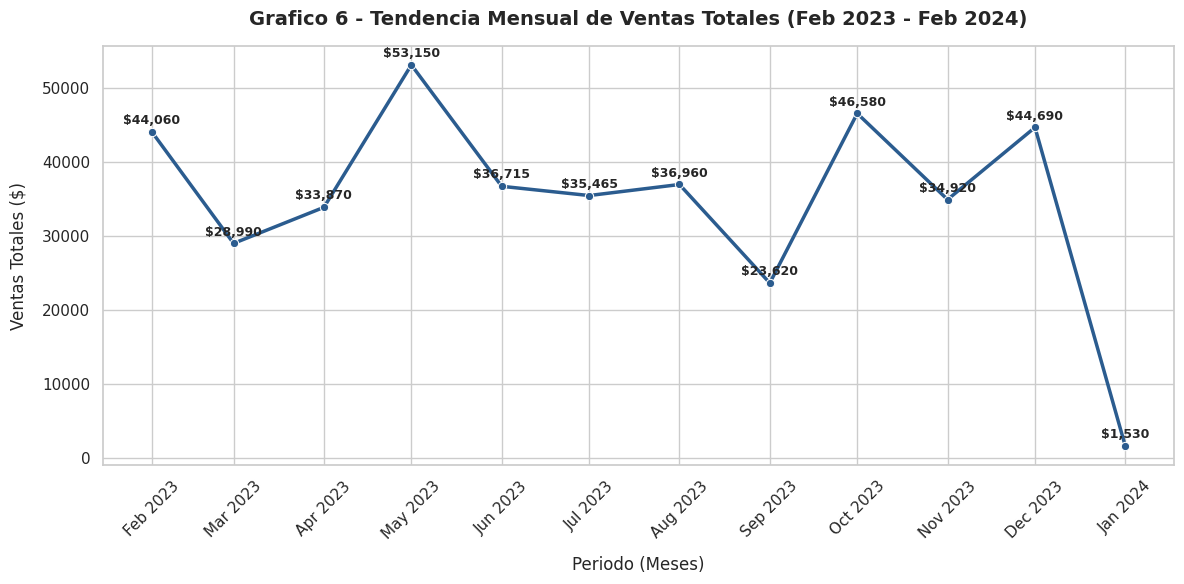

In [30]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

# Dibujar la línea de tendencia con marcadores en cada mes
sns.lineplot(
    data=ventas_filtradas,
    x='Year_Month',
    y='Total Amount',
    marker='o',
    linewidth=2.5,
    color='#2b5c8f',
    ax=ax
)

# Personalización estética del gráfico
ax.set_title('Grafico 6 - Tendencia Mensual de Ventas Totales (Feb 2023 - Feb 2024)', fontsize=14, pad=15, weight='bold')
ax.set_xlabel('Periodo (Meses)', fontsize=12, labelpad=10)
ax.set_ylabel('Ventas Totales ($)', fontsize=12, labelpad=10)

# Formatear el eje X para que muestre los nombres de los meses claramente
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Rotar las etiquetas del eje X para que no se superpongan
plt.xticks(rotation=45)

# Añadir anotaciones con el valor de cada mes sobre los puntos para facilitar la lectura
for index, row in ventas_filtradas.iterrows():
    ax.text(
        row['Year_Month'],
        row['Total Amount'] + (ventas_filtradas['Total Amount'].max() * 0.02), # Pequeño desfase hacia arriba
        f"${row['Total Amount']:,.0f}",
        ha='center',
        fontsize=9,
        weight='semibold'
    )

plt.tight_layout()
plt.show()
# Exportar la imagen en alta definición
fig.savefig('grafico3.png', dpi=300, bbox_inches='tight')
plt.close(fig)


Grafico #6. el negocio muestra una alta votalidad en la facturacion mensual, alternando con picos de alta demanda y cidad pronunciadas cada 3 -4  meses, bien no hya informacion sobre la ubicacion del negocio la cual pueda correlacionarce para comprender las altas demandas y caidas en el tiempo. aun que se pueden suponer situaciones que afecta la demanda estas no son medibles.

###Diagrama de Dispersión: Edad vs Total Amount (Segmentado por Género)

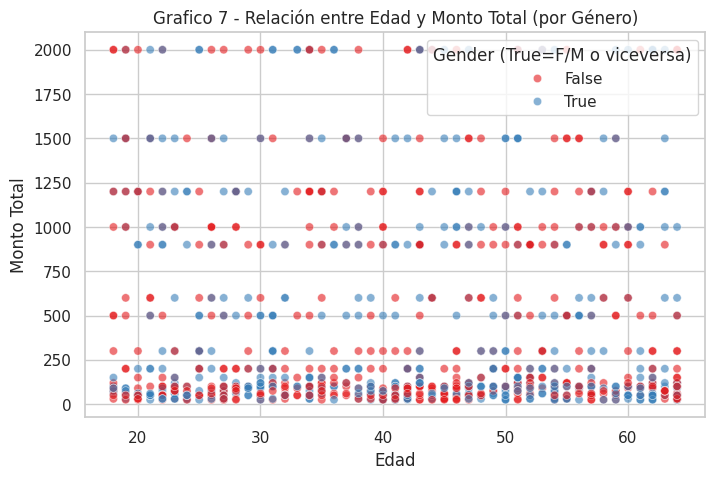

In [31]:
plt.figure(figsize=(8, 5))
fig = plt.gcf()
sns.scatterplot(data=df, x='Age', y='Total Amount', hue='Gender', alpha=0.6, palette='Set1')
plt.title('Grafico 7 - Relación entre Edad y Monto Total (por Género)')
plt.xlabel('Edad')
plt.ylabel('Monto Total')
plt.legend(title='Gender (True=F/M o viceversa)')
plt.show()
fig.savefig('grafico4.png', dpi=300, bbox_inches='tight')
plt.close(fig)

Grafico #7. este gráfico te da una conclusión clave, la segmentación por edad no sirve para predecir el valor del ticket de compra. No puedes asumir que el público más maduro gasta más por tener mayor poder adquisitivo, ni que los jóvenes compran solo lo más barato. Dado que el comportamiento de gasto es idéntico

###Mapa de Calor (Heatmap) de Correlación

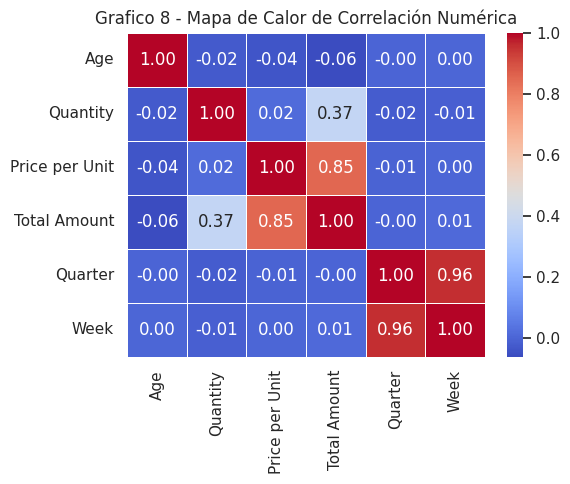

In [32]:
num_cols = [col for col in df.select_dtypes(include=['number'])]
# Mapa de Calor (Heatmap) de Correlación
fig = plt.figure(figsize=(6, 5))
# Seleccionamos solo las columnas numéricas para la correlación
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Grafico 8 - Mapa de Calor de Correlación Numérica')
plt.tight_layout()
plt.show()
fig.savefig('grafico5.png', dpi=300, bbox_inches='tight')
plt.close(fig)

Grafico #8. El heatmap entrega un diagnóstico estratégico para el negocio, el crecimiento de los ingresos está guiado por el valor del producto (Price per Unit) y y por la  seman cuando fue realizada la compra(Week)

##Preprocesamiento DataSet

In [33]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month', 'Quarter', 'Week', 'Year_Month', 'purchase_level'],
      dtype='object')

Importe Libreria SKlearn

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

###Separacion features y Target

In [55]:
X = df.drop(columns=['Total Amount', 'Date', 'Year_Month', 'Customer ID', 'Transaction ID'])
y = df['Total Amount']

###Deteccion de Columnas


In [56]:
print(df.dtypes)

Transaction ID              object
Date                datetime64[ns]
Customer ID                 object
Gender                        bool
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
Month                       object
Quarter                      int64
Week                         int64
Year_Month               period[M]
purchase_level              object
dtype: object


In [57]:
numeric_features = list(X.select_dtypes(include=['float64', 'int', 'bool' ]).columns)
categorical_features = list(X.select_dtypes(include=['object', 'category']).columns)

print(f'Categóricas ({len(categorical_features)}): {categorical_features}')
print(f'Numéricas ({len(numeric_features)}): {numeric_features}')

Categóricas (3): ['Product Category', 'Month', 'purchase_level']
Numéricas (6): ['Gender', 'Age', 'Quantity', 'Price per Unit', 'Quarter', 'Week']


###Train/test split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')


Train: (800, 9)  |  Test: (200, 9)


###Column Transformer Numerico

In [59]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


###Column Transformer Categorico

In [60]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])


###Column Transform Preprocesamiento

In [61]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
],
                                 remainder='passthrough'
)


In [62]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Gender', 'Age', 'Quantity', 'Price per Unit',
                                  'Quarter', 'Week']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Product Category', 'Month',
                                  'purchase_level'])])

##Entrenamiento de Modelos

In [63]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f'Shape tras preprocesar — train: {X_train_prep.shape}')
print(f'Features generadas: {X_train_prep.shape[1]} (desde {X_train.shape[1]} columnas originales)')



Shape tras preprocesar — train: (800, 24)
Features generadas: 24 (desde 9 columnas originales)


In [72]:
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor # Explicitly import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time
import pandas as pd # Import pandas for DataFrame creation
import numpy as np  # Import numpy for sqrt

modelos = {
    'Árbol(d=10)':      DecisionTreeRegressor(max_depth=10, random_state=42),
    'RandomForest(200)': RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42),
}



##Metricas

In [71]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time

resultados = []
for nombre, modelo in modelos.items():
    t_inicio = time.time()
    modelo.fit(X_train_prep, y_train)
    t_fit = time.time() - t_inicio

    t_inicio = time.time()
    pred = modelo.predict(X_test_prep)
    t_pred = time.time() - t_inicio

    resultados.append({
        'Modelo': nombre,
        'R²':         r2_score(y_test, pred),
        'MAE':        mean_absolute_error(y_test, pred),
        'RMSE':       np.sqrt(mean_squared_error(y_test, pred)),
        'Tiempo fit (s)':  round(t_fit, 2),
        'Tiempo pred (s)': round(t_pred, 3)
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
tabla

,R²,MAE,RMSE,Tiempo fit (s),Tiempo pred (s)
Modelo,,,,,
Árbol(d=10),1.0,0.0,0.0,0.01,0.001
RandomForest(200),1.0,0.0,0.0,0.51,0.037


Ambos modelos arrojan un coeficiente igual 1, lo cual levanta inmediatamente las alerta de que los modelos se sobre ajustaron.

##Hiperparametros Con GridSearchCV

In [74]:
from sklearn.model_selection import GridSearchCV

# Definir el modelo base + grilla de hiperparámetros a probar
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [390,400,410],
    'max_depth':    [25,26,27,28]
}

# GridSearch con 3-fold CV (3 splits dentro del train) — total: 3×3×3 = 27 entrenamientos
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,                  # 3-fold CV
    scoring='r2',          # métrica a optimizar
    n_jobs=-1,             # paralelización
    verbose=1
)

print('Entrenando 27 combinaciones (3×3 hiperparámetros × 3 CV folds)...')
grid.fit(X_train_prep, y_train)

print(f'\n🏆 Mejores hiperparámetros: {grid.best_params_}')
print(f'   Mejor R² (CV):           {grid.best_score_:.4f}')
print(f'   R² en test:              {grid.score(X_test_prep, y_test):.4f}')

Entrenando 27 combinaciones (3×3 hiperparámetros × 3 CV folds)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

🏆 Mejores hiperparámetros: {'max_depth': 25, 'n_estimators': 410}
   Mejor R² (CV):           1.0000
   R² en test:              1.0000


In [75]:
from sklearn.model_selection import GridSearchCV

# Definir el modelo base + grilla de hiperparámetros a probar
tree = DecisionTreeRegressor(random_state=42)

param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': [3, 4, 5, 6, 7, 8, 10],          # Evita que el árbol crezca al infinito (causa del d=10 con R²=1)
    'min_samples_split': [2, 5, 10, 20],         # Número mínimo de muestras para abrir un nuevo nodo
    'min_samples_leaf': [1, 2, 4, 8, 12],         # Número mínimo de muestras que deben quedar en una hoja
    'max_features': [None, 'sqrt', 'log2']        # Número de variables a considerar en cada división

}

# GridSearch con 3-fold CV (3 splits dentro del train) — total: 3×3×3 = 27 entrenamientos
grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=3,                  # 3-fold CV
    scoring='r2',          # métrica a optimizar
    n_jobs=-1,             # paralelización
    verbose=1
)

print('Entrenando 27 combinaciones (3×3 hiperparámetros × 3 CV folds)...')
grid.fit(X_train_prep, y_train)

print(f'\n🏆 Mejores hiperparámetros: {grid.best_params_}')
print(f'   Mejor R² (CV):           {grid.best_score_:.4f}')
print(f'   R² en test:              {grid.score(X_test_prep, y_test):.4f}')

Entrenando 27 combinaciones (3×3 hiperparámetros × 3 CV folds)...
Fitting 3 folds for each of 1260 candidates, totalling 3780 fits

🏆 Mejores hiperparámetros: {'criterion': 'squared_error', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
   Mejor R² (CV):           1.0000
   R² en test:              1.0000


##Entrenamiento de Modelos Con Hiperparametros

In [78]:
modelos = {
    'Árbol(d=10)':      DecisionTreeRegressor(criterion='squared_error', max_depth=6, max_features=None, min_samples_leaf=1, min_samples_split=2, random_state=42),
    'RandomForest(200)': RandomForestRegressor(n_estimators=410, max_depth=25, n_jobs=-1, random_state=42),
}

##Metricas de Modelos Con Hiperparametros

In [79]:
resultados = []
for nombre, modelo in modelos.items():
    t_inicio = time.time()
    modelo.fit(X_train_prep, y_train)
    t_fit = time.time() - t_inicio

    t_inicio = time.time()
    pred = modelo.predict(X_test_prep)
    t_pred = time.time() - t_inicio

    resultados.append({
        'Modelo': nombre,
        'R²':         r2_score(y_test, pred),
        'MAE':        mean_absolute_error(y_test, pred),
        'RMSE':       np.sqrt(mean_squared_error(y_test, pred)),
        'Tiempo fit (s)':  round(t_fit, 2),
        'Tiempo pred (s)': round(t_pred, 3)
    })

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
tabla

,R²,MAE,RMSE,Tiempo fit (s),Tiempo pred (s)
Modelo,,,,,
Árbol(d=10),1.0,0.0,0.0,0.01,0.001
RandomForest(200),1.0,0.0,0.0,2.22,0.220


Aun aplicando los hiperparametros determinados popr GridSearchCV los modelos arrojan coeficientes igual 1 que indican que no estan detectando patrones que puedan generar predicciones.

#Conclusiones

In [ ]:
'''

A continuación, se detallan los hallazgos clave y el diagnóstico técnico de los resultados:

el primer entrenamiento de los modelos arroja de forma categorica un coeficiente 1, sabemos que esto se puede interpretar como un 100% eficiencia, pero la realidad es que no existe un modelo perfecto, esto se traduce en sobreajuste o sea el modelo emorizo datos y no es capaz de predecir el monto de ventas de testeo y futuras.

El hecho de que el HeatMap mostrará  una casi nula correlacion entre las variable numericas ya no indicaba que la dataset  no posee la data necesaria para entrener un modelo que pudiera predecir  con  un porcentaje razonable de certeza el monto de ventas, o bien esta dataset es inventado lo cual explicaria la casi nula correlacion entre las variables numerico. Incluso le utilizo LazyPredict para buscar alternativas y los resultados fueron exatamente los mismos.

En terminos generales es imposible generar un modelo que pueda genera la prediccion de monto de las ventas para retail


'''

#Adicionales

In [81]:
try:
    from lazypredict.Supervised import LazyRegressor
    reg = LazyRegressor(verbose=0, ignore_warnings=True)
    # X_train_prep and X_test_prep are already dense numpy arrays, no need to call .toarray()
    modelos_lazy, _ = reg.fit(X_train_prep, X_test_prep, y_train, y_test)
    print('Top 10 modelos por R²:')
    display(modelos_lazy.head(10))
except ImportError:
    print('⚠️ LazyPredict no instalado. Corre: !pip install lazypredict')

Top 10 modelos por R²:


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
BaggingRegressor,1.000000,1.000000,0.000000,0.046626
DecisionTreeRegressor,1.000000,1.000000,0.000000,0.019638
ExtraTreesRegressor,1.000000,1.000000,0.000000,0.215847
ExtraTreeRegressor,1.000000,1.000000,0.000000,0.014748
RandomForestRegressor,1.000000,1.000000,0.000000,0.288942
XGBRegressor,1.000000,1.000000,0.000120,0.166717
LGBMRegressor,1.000000,1.000000,0.014373,0.058589
HistGradientBoostingRegressor,1.000000,1.000000,0.014373,0.206525
GradientBoostingRegressor,0.999956,0.999961,3.372073,0.220982


In [82]:
modelos_lazy

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
BaggingRegressor,1.000000,1.000000,0.000000,0.046626
DecisionTreeRegressor,1.000000,1.000000,0.000000,0.019638
ExtraTreesRegressor,1.000000,1.000000,0.000000,0.215847
ExtraTreeRegressor,1.000000,1.000000,0.000000,0.014748
RandomForestRegressor,1.000000,1.000000,0.000000,0.288942
XGBRegressor,1.000000,1.000000,0.000120,0.166717
LGBMRegressor,1.000000,1.000000,0.014373,0.058589
HistGradientBoostingRegressor,1.000000,1.000000,0.014373,0.206525
GradientBoostingRegressor,0.999956,0.999961,3.372073,0.220982
